# Temporal MSAA

In [1]:
%matplotlib inline

In [2]:
#imports 
import warnings
import os
import pandas as pd
import seaborn as sns
import numpy as np
import networkx as netx
import pywt
import matplotlib.pyplot as plt
import matplotlib.style as style
import matplotlib.cm as cm
from scipy.io import loadmat
from scipy.spatial.distance import cdist
import scipy
from sklearn.manifold import LocallyLinearEmbedding
import nilearn as nl             # pip: nilearn==0.10.0
from nilearn.maskers import NiftiMasker
import nibabel as nib
import nltools as nlt
from matplotlib.colors import ListedColormap
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from itertools import compress
from scipy.optimize import minimize
import sys, pathlib, importlib.util
import time

In [3]:
sys.path.insert(0, str(pathlib.Path('hypertools').resolve()))

spec = importlib.util.spec_from_file_location('normalize', 'hypertools/normalize.py')
ht = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ht)

sys.path.append("helpers")

from MultiSubject_AA_T import SubjectT, multi_subject_aa_T 

Runtime (s): 0.137
Variance explained: 23.38%
C shape: (20, 10)
Subject 0: S shape (10, 40) sXC shape (300, 10)


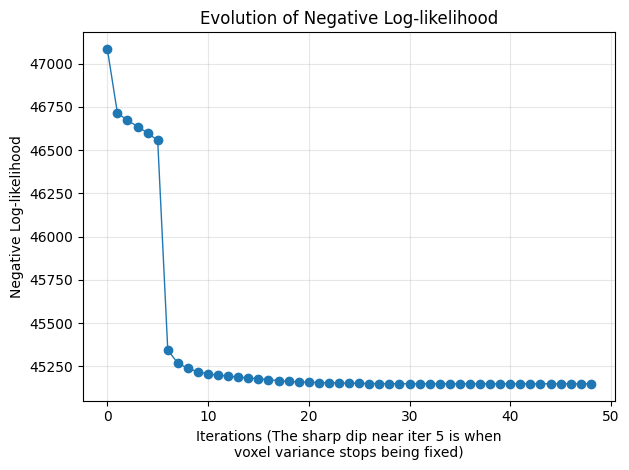

Subject 0 SSE (recomputed): 9056.1651
Subject 0 SSE (from results): 9056.1651


In [6]:
# -----------------------------
# Problem setting
# -----------------------------
noc       = 10      # number of components
B         = 3       # number of subjects
Timesteps = 40      # observations (time)
Voxels    = 300     # dimensions (voxels)

rng = np.random.default_rng(123)  # only for synthetic data generation

# -----------------------------
# Data generation
# (Archetypes XC are spatial with spatial noise: X is Voxels x Time)
# -----------------------------
subj = []
for _ in range(B):
    X = rng.standard_normal((Voxels, Timesteps))  # double precision by default (float64)
    X = X - X.mean(axis=1, keepdims=True)         # zero mean over time per voxel
    sX = X[:, :int(np.ceil(Timesteps / 2))]       # can also be X; here we mimic MATLAB's half-time search space
    subj.append(SubjectT(X=X, sX=sX))

# -----------------------------
# Alternative (commented): Temporal archetypes w/ temporal noise
# In contrast to regular MS-AA, which has temporal archetypes but spatial noise.
# Here X would be Time x Voxels; you'd need the SPATIAL version of the algorithm (multi_subject_aa),
# not the _T variant. Shown here just to mirror your MATLAB comments.
#
# subj = []
# for _ in range(B):
#     X = rng.standard_normal((Timesteps, Voxels))
#     X = X - X.mean(axis=0, keepdims=True)
#     sX = X[:, :int(np.ceil(Voxels / 2))]
#     # NOTE: If you switch to this orientation, call the spatial algorithm instead.
# -----------------------------

# -----------------------------
# Optimization parameters
# -----------------------------
opts = {
    "maxiter":         100,
    "conv_crit":       1e-8,
    "fix_var_iter":    5,
    "use_gpu":         False,     # set True if CuPy is installed and you want GPU
    "heteroscedastic": True,
    "rngSEED":         12345,     # fix algorithmic randomness (init & furthest-sum)
    # other knobs:
    # "init":          "FurthestSum",  # default
    # "numCstep":      10,
    # "numSstep":      20,
    # "initSstep":     250,
    # "noise_threshold": <float>,
}

# -----------------------------
# Run temporal MS-AA
# -----------------------------
results_subj, C, cost_fun, varexpl, time_taken = multi_subject_aa_T(subj, noc, opts)

print(f"Runtime (s): {time_taken:.3f}")
print(f"Variance explained: {varexpl*100:.2f}%")
print("C shape:", C.shape)
print("Subject 0: S shape", results_subj[0]["S"].shape, "sXC shape", results_subj[0]["sXC"].shape)

# -----------------------------
# Plot the negative log-likelihood
# -----------------------------
plt.figure()
plt.plot(cost_fun, marker="o", linewidth=1)
plt.title("Evolution of Negative Log-likelihood")
plt.xlabel(
    f"Iterations (The sharp dip near iter {opts['fix_var_iter']} is when\n"
    "voxel variance stops being fixed)"
)
plt.ylabel("Negative Log-likelihood")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# Quick consistency check (SSE recompute)
# -----------------------------
b = 0
recon0 = (subj[b].sX @ C) @ results_subj[b]["S"]  # (V,T)
fro_err0 = np.linalg.norm(subj[b].X - recon0, ord="fro")**2
print(f"Subject 0 SSE (recomputed): {fro_err0:.4f}")
print(f"Subject 0 SSE (from results): {results_subj[b]['SSE']:.4f}")


In [4]:
# test with real data
pieman_name = 'data/pieman/raw/pieman_data.mat'
pieman_data = loadmat(pieman_name)
pieman_conds = ['intact', 'paragraph', 'word', 'rest']

In [5]:
posterior = loadmat('data/pieman/raw/pieman_posterior_K700.mat')
centers = posterior['posterior']['centers'][0][0][0][0][0]
widths = np.array(list(posterior['posterior']['widths'][0][0][0][0][0][:, 0].T))

In [6]:
data = []
conds = []
for c in pieman_conds:
    if c == 'paragraph':
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.where(np.arange(pieman_data[c].shape[1]) != 3)[0]))
    else:
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.arange(pieman_data[c].shape[1])))
    data.extend(next_data)
    conds.extend([c]*len(next_data))


In [7]:
def coerce_VxT(x):
    x = np.asarray(x)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D array, got {x.shape}")
    # Heuristic: if "time" accidentally sits in rows, transpose to VxT
    # We expect T << V in fMRI (hundreds vs thousands).
    V, T = x.shape
    if V < T:
        x = x.T  # now V x T
        V, T = x.shape
    # zero-mean per voxel (row) across time
    x = x - x.mean(axis=1, keepdims=True)
    return x.astype(np.float32, copy=False)

def array_cutter(data_list, cut_length): 
    data_list_new = data_list
    for subject in range(len(data_list)):
        data_list_new[subject] = data_list_new[subject][:-cut_length]
    return data_list_new

In [8]:
conds_array = np.array(conds)
intact_list = [data[i] for i in np.where(conds_array=='intact')[0]]
paragraph_list = [data[i] for i in np.where(conds_array=='paragraph')[0]]
word_list = [data[i] for i in np.where(conds_array=='word')[0]]
rest_list = [data[i] for i in np.where(conds_array=='rest')[0]]

In [14]:
# run this if you want to cut last 100 timepoints off of rest
rest_list = array_cutter(rest_list, 100)

In [9]:
# data groups
intact_norm = ht.normalize(intact_list, normalize = 'across')
paragraph_norm = ht.normalize(paragraph_list, normalize = 'across')
word_norm = ht.normalize(word_list, normalize = 'across')
rest_norm = ht.normalize(rest_list, normalize = 'across')

/opt/homebrew/anaconda3/envs/archs/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
condition_data = {
    'intact': intact_norm,
    'word':   word_norm,
    'rest':   rest_norm,
}

all_results = {}

# Loop over each condition, run MS-AA_T, store results
for cond_name, cond_subject_arrays in condition_data.items():
    # cond_subject_arrays: list of per-subject (T,V) arrays that need to be transposed

    subj_objs = [
        SubjectT(
            X=coerce_VxT(X),   # ensures (V, T), float32, zero-mean per voxel
            sX=coerce_VxT(X),  # no reduced basis, so sX == X
        )
        for X in cond_subject_arrays
    ]

    opts = dict(
        maxiter=100,
        conv_crit=1e-6,
        fix_var_iter=5,
        heteroscedastic=False,
        use_gpu=False, 
        rngSEED=12345,
    )

    K = 50  # archetypes
    results_subj, C, cost_fun, varexpl, secs = multi_subject_aa_T(
        subj_objs,
        noc=K,
        opts=opts
    )

    print(f"[{cond_name}] runtime {secs:.1f}s | VarExpl {varexpl*100:.2f}%")
    print("  C shape:", C.shape)                                   # (sV, K)
    print("  subj0 sXC shape:", results_subj[0]["sXC"].shape)       # expected (T, K)
    print("  subj0 S shape:",   results_subj[0]["S"].shape)         # expected (K, V)

    # Store everything for later
    all_results[cond_name] = {
        "results_subj": results_subj,  # list, one dict per subject
        "C": C,                        # shared archetype generator / "basis"
        "cost_fun": cost_fun,          # NLL trace over iterations
        "varexpl": varexpl,            # scalar
        "secs": secs,
        "K": K,
        "opts": opts,
    }

[intact] runtime 306.9s | VarExpl 52.60%
  C shape: (300, 50)
  subj0 sXC shape: (700, 50)
  subj0 S shape: (50, 300)
[word] runtime 494.7s | VarExpl 56.44%
  C shape: (300, 50)
  subj0 sXC shape: (700, 50)
  subj0 S shape: (50, 300)
[rest] runtime 163.2s | VarExpl 45.76%
  C shape: (400, 50)
  subj0 sXC shape: (700, 50)
  subj0 S shape: (50, 400)


In [16]:
import numpy as np
try:
    from scipy.optimize import linear_sum_assignment
except Exception:
    linear_sum_assignment = None

def _norm_cols(X, eps=1e-12):
    nrm = np.linalg.norm(X, axis=0, keepdims=True)
    return X / np.maximum(nrm, eps)

def column_matched_cosine_C_vs_S(C, S_kxV, weights=None, eps=1e-12, return_details=True):
    """
    C:        (V, K)   group archetypes over nodes (V=700)
    S_kxV:    (K, V)   subject archetypes over nodes but as rows
    weights:  (K,)     optional weights per *group* archetype (e.g., sum over sXC columns)
    """
    V, K = C.shape
    Ks, Vs = S_kxV.shape
    if Vs != V:
        raise ValueError(f"S_kxV has V={Vs} but C has V={V}. Align node order first.")
    # Put subject archetypes in column form (V, Ks)
    S_cols = S_kxV.T
    Cn = _norm_cols(C)          # (V, K)
    Sn = _norm_cols(S_cols)     # (V, Ks)
    S_cos = Cn.T @ Sn           # (K, Ks)

    # Max-sum assignment on S_cos
    if linear_sum_assignment is not None:
        row_inds, col_inds = linear_sum_assignment(-S_cos)  # maximize similarity
    else:
        # Greedy fallback if SciPy isn't available
        Kmin = min(K, Ks)
        used_r, used_c, pairs = set(), set(), []
        for _ in range(Kmin):
            best = (-np.inf, None, None)
            for r in range(K):
                if r in used_r: continue
                for c in range(Ks):
                    if c in used_c: continue
                    val = S_cos[r, c]
                    if val > best[0]:
                        best = (val, r, c)
            _, r, c = best
            used_r.add(r); used_c.add(c); pairs.append((r, c))
        row_inds = np.array([r for r,_ in pairs], dtype=int)
        col_inds = np.array([c for _,c in pairs], dtype=int)

    pair_sims = S_cos[row_inds, col_inds]

    if weights is not None:
        w = np.asarray(weights, float)
        if w.shape[0] != K:
            raise ValueError(f"`weights` must have length {K}, got {w.shape[0]}")
        w_matched = w[row_inds]
        w_matched = w_matched / (w_matched.sum() + eps)
        mean_sim = float((w_matched * pair_sims).sum())
    else:
        mean_sim = float(pair_sims.mean())

    details = {
        "row_inds": row_inds,              # indices into C's columns
        "col_inds": col_inds,              # indices into S_cols' columns == rows of S_kxV
        "pair_sims": pair_sims,
        "similarity_matrix": S_cos,
    }
    return (mean_sim, details) if return_details else mean_sim

def per_subject_similarity(C, subjects, weight_by_usage=True):
    """
    subjects: list/dict-like with entries {'S': (K, V), 'sXC': (T, K)}
    returns:  DataFrame with per-subject similarity + the permutation used
    """
    rows = []
    for s_idx, sub in enumerate(subjects):
        S = sub["S"]           # (K, 700)
        sXC = sub["sXC"]       # (300, K)
        weights = sXC.sum(axis=0) if weight_by_usage else None
        sim, info = column_matched_cosine_C_vs_S(C, S, weights=weights, return_details=True)
        rows.append({
            "subject": s_idx,
            "mean_matched_cosine": sim,
            "assignment_group_cols": info["row_inds"],
            "assignment_subject_rows": info["col_inds"],
            "pairwise_sims": info["pair_sims"],
        })
    return pd.DataFrame(rows)


def reconstruct_subject(sub, C=None, basis="group", zscore_time=False, zscore_nodes=False, eps=1e-8):
    """
    sub:   dict with 'S' (K, V) and 'sXC' (T, K)
    C:     (V, K) group archetypes (required if basis='group')
    basis: 'group' -> Xhat = sXC @ C.T
           'subject' -> Xhat = sXC @ S
    Optional z-scoring to stabilize correlation distances for decoding.
    """
    sXC = sub["sXC"]  # (T, K)
    S   = sub["S"]    # (K, V)
    if basis == "group":
        if C is None: raise ValueError("Provide C when basis='group'.")
        Xhat = sXC @ C.T          # (T, V)
    elif basis == "subject":
        Xhat = sXC @ S            # (T, V)
    else:
        raise ValueError("basis must be 'group' or 'subject'")

    # Optional normalizations for correlation-based decoding
    if zscore_time:
        # z-score each node across time (remove slow drifts / mean differences)
        Xhat = (Xhat - Xhat.mean(axis=0, keepdims=True)) / (Xhat.std(axis=0, keepdims=True) + eps)
    if zscore_nodes:
        # z-score each timepoint across nodes
        Xhat = (Xhat - Xhat.mean(axis=1, keepdims=True)) / (Xhat.std(axis=1, keepdims=True) + eps)
    return Xhat  # (T, V)
    
def build_recon_stack(subjects, C, basis="group", zscore_time=True, zscore_nodes=False):
    Xhats = []
    for sub in subjects:
        Xhats.append(reconstruct_subject(sub, C=C, basis=basis,
                                         zscore_time=zscore_time,
                                         zscore_nodes=zscore_nodes))
    return np.stack(Xhats, axis=0)  # (N, T, V)
    
from scipy.spatial.distance import cdist

def get_xval_assignments(ndata, nfolds, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    group_assignments = np.zeros(ndata, dtype=int)
    groupsize = int(np.ceil(ndata / nfolds))
    for i in range(1, nfolds):
        inds = np.arange(i * groupsize, min((i + 1) * groupsize, ndata))
        group_assignments[inds] = i
    rng.shuffle(group_assignments)
    return group_assignments  # length ndata of fold IDs 0..nfolds-1

def decoder(corrs):
    next_results_pd = pd.DataFrame({'rank':[0.0], 'accuracy':[0.0], 'error':[0.0]})
    for t in range(corrs.shape[0]):
        decoded_inds = int(np.argmax(corrs[t, :]))
        next_results_pd.loc[0, 'error']    += np.mean(np.abs(decoded_inds - t)) / corrs.shape[0]
        next_results_pd.loc[0, 'accuracy'] += (decoded_inds == t)
        next_results_pd.loc[0, 'rank']     += np.mean((corrs[t, :] <= corrs[t, t]).astype(int))
    next_results_pd['error']    /= corrs.shape[0]
    next_results_pd['accuracy'] /= corrs.shape[0]
    next_results_pd['rank']     /= corrs.shape[0]
    return next_results_pd

def run_timepoint_decoding(recon_stack, nfolds=2, nreps=1, seed=0):
    """
    recon_stack: (N, T, V) array of reconstructed subject data
    Returns a DataFrame with metrics per repetition and fold.
    """
    N, T, V = recon_stack.shape
    rng = np.random.default_rng(seed)
    all_results = []

    for f in range(nreps):
        fold_ids = get_xval_assignments(N, nfolds, rng=rng)
        for i in range(nfolds):
            in_mask  = (fold_ids == i)
            out_mask = ~in_mask
            # Mean across subjects in fold and out-of-fold → (T, V)
            in_smooth  = recon_stack[in_mask].mean(axis=0)
            out_smooth = recon_stack[out_mask].mean(axis=0)
            # Time × Time correlation similarity (cdist with 'correlation' gives 1 - Pearson)
            corrs = 1.0 - cdist(in_smooth, out_smooth, metric='correlation')  # (T, T)
            next_results_pd = decoder(corrs)
            next_results_pd['rep']  = f
            next_results_pd['fold'] = i
            all_results.append(next_results_pd)

    results_pd = pd.concat(all_results, ignore_index=True)
    return results_pd


def compute_energy_array(group_archs_array, group_coeffs_array):
    """
    Returns: energies (N, K)
      E[s, k] = ||A_s[:,k]||^2 * ||S_s[k,:]||^2
    """
    N, T, K = group_archs_array.shape
    N2, K2, V = group_coeffs_array.shape
    assert N == N2 and K == K2, "Subject or archetype count mismatch."

    # ||A_s[:,k]||^2  -> (N, K)
    a2 = np.sum(group_archs_array**2, axis=1)  # (N, K)

    # ||S_s[k,:]||^2  -> (N, K)
    s2 = np.sum(group_coeffs_array**2, axis=2) # (N, K)

    energies = a2 * s2                          # (N, K)
    return energies

def build_energy_df(energies, condition_labels, cond_map=None, log1p=True, zscore=False):
    """
    energies: (N, K)
    condition_labels: (N,) (ints 0/1/2)
    cond_map: optional dict {0:'Intact', 1:'Scrambled', 2:'Other'}
    Returns df with columns: ['Condition','Subject','A1',...'AK']
    """
    N, K = energies.shape
    E = energies.copy()

    if log1p:
        E = np.log1p(E)  # stabilizes heavy tails

    if zscore:
        # z-score each archetype across subjects (optional)
        scaler = StandardScaler()
        E = scaler.fit_transform(E)

    df = pd.DataFrame(E, columns=[f"A{i+1}" for i in range(K)])
    if cond_map:
        df["Condition"] = pd.Series(condition_labels).map(cond_map).astype("category")
    else:
        df["Condition"] = condition_labels
    df["Subject"] = np.arange(N)
    return df

def plot_top_energy_archetype_per_subject(df_energy, title="Most energetic archetype per subject"):
    energy_cols = [c for c in df_energy.columns if c.startswith("A")]
    top_idx = df_energy[energy_cols].to_numpy().argmax(axis=1) + 1  # 1-based
    df_top = df_energy[["Condition","Subject"]].copy()
    df_top["TopArchetype"] = top_idx

    plt.figure(figsize=(9,4))
    sns.countplot(data=df_top, x="TopArchetype", hue="Condition")
    plt.title(title)
    plt.xlabel("Archetype index")
    plt.ylabel("# Subjects")
    plt.tight_layout()
    plt.show()
    return df_top

def classify_condition_from_energy(df_energy, n_splits=5, top_m=None, random_state=42):
    """
    Logistic regression on subject-level archetype energy profiles.
    If top_m is provided, select top_m archetypes by coefficient magnitude (nested quick pass).
    """
    # label vector
    y = pd.Categorical(df_energy["Condition"]).codes
    energy_cols = [c for c in df_energy.columns if c.startswith("A")]
    X_full = df_energy[energy_cols].to_numpy()

    # (optional) pick top_m features by a quick fit on full X
    sel_cols = energy_cols
    if top_m is not None and top_m < len(energy_cols):
        clf0 = LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="auto")
        clf0.fit(X_full, y)
        imp = np.abs(clf0.coef_).mean(axis=0)
        top_idx = np.argsort(imp)[::-1][:top_m]
        sel_cols = [energy_cols[i] for i in top_idx]

    X = df_energy[sel_cols].to_numpy()

    # CV accuracy
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="auto")
    scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
    clf.fit(X, y)

    print(f"Condition decoding (energies, features={len(sel_cols)}): "
          f"{scores.mean():.3f} ± {scores.std():.3f}")
    # Return feature importance on the chosen set
    importance = np.abs(clf.coef_).mean(axis=0)
    imp_df = pd.DataFrame({"Feature": sel_cols, "Importance": importance}).sort_values("Importance", ascending=False)
    return clf, scores, imp_df

def plot_energy_importance(imp_df, top_n=20, title="Archetype importance for condition decoding"):
    top = imp_df.head(top_n)
    plt.figure(figsize=(8,4))
    sns.barplot(data=top, x="Feature", y="Importance", color="steelblue")
    plt.xticks(rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()



def _lag1_autocorr(x):
    x = np.asarray(x)
    x = x - x.mean()
    denom = np.dot(x, x)
    if denom == 0 or np.isnan(denom):
        return 0.0
    num = np.dot(x[:-1], x[1:])
    if np.isnan(num):
        return 0.0
    return float(num / denom)

def _spectral_entropy(x, fs, nperseg=None):
    from scipy.signal import welch
    from scipy.stats import entropy
    f, Pxx = welch(x, fs=fs, nperseg=nperseg or min(256, len(x)))
    if np.sum(Pxx) == 0 or np.isnan(np.sum(Pxx)):
        return 0.0
    P = Pxx / (np.sum(Pxx) + 1e-12)
    return float(entropy(P))

def _band_power(x, fs, band, nperseg=None):
    from scipy.signal import welch
    f, Pxx = welch(x, fs=fs, nperseg=nperseg or min(256, len(x)))
    if np.all(Pxx == 0):
        return 0.0
    idx = (f >= band[0]) & (f < band[1])
    return float(np.trapz(Pxx[idx], f[idx])) if idx.any() else 0.0


def compute_temporal_feature_df(
    group_archs_array,       # (N, T, K)
    group_coeffs_array,      # (N, K, V)
    condition_labels,        # (N,)
    fs=0.5,                  # sampling rate (Hz); set to your TR^-1 or what you prefer
    bands=((0.01,0.08),(0.08,0.2)),  # sample bands; tweak to your data
    add_log1p_energy=True,
    zscore_across_subjects=False
):
    """
    Returns a subject-level feature dataframe with columns like:
      A{k}_energy, A{k}_mean, A{k}_std, A{k}_ac1, A{k}_specent, A{k}_bp_0, A{k}_bp_1 ...
    """
    N, T, K = group_archs_array.shape
    # energy = ||A[:,k]||^2 * ||S[k,:]||^2
    a2 = np.sum(group_archs_array**2, axis=1)      # (N, K)  ||A||^2 per archetype
    s2 = np.sum(group_coeffs_array**2, axis=2)     # (N, K)  ||S||^2 per archetype
    energy = a2 * s2                               # (N, K)

    rows = []
    for s in range(N):
        feats = {"Subject": s, "Condition": int(condition_labels[s])}
        for k in range(K):
            a = group_archs_array[s, :, k]
            # basic stats
            feats[f"A{k+1}_energy"]   = energy[s, k]
            feats[f"A{k+1}_mean"]     = float(np.mean(a))
            feats[f"A{k+1}_std"]      = float(np.std(a))
            feats[f"A{k+1}_ac1"]      = _lag1_autocorr(a)
            feats[f"A{k+1}_specent"]  = _spectral_entropy(a, fs)
            # band powers
            for b_idx, band in enumerate(bands):
                feats[f"A{k+1}_bp{b_idx}"] = _band_power(a, fs, band)
        rows.append(feats)

    df = pd.DataFrame(rows)

    # optional transforms
    if add_log1p_energy:
        for k in range(K):
            col = f"A{k+1}_energy"
            df[col] = np.log1p(df[col])

    if zscore_across_subjects:
        from sklearn.preprocessing import StandardScaler
        cols = [c for c in df.columns if c not in ("Subject","Condition")]
        df[cols] = StandardScaler().fit_transform(df[cols])

    return df


def classify_with_temporal_features(df_features, n_splits=5, top_m_archetypes=None, random_state=42):
    """
    Train subject-level classifier on temporal summary features.
    If top_m_archetypes is set, select the top-M archetypes by aggregated importance (coef magnitude).
    """
    y = pd.Categorical(df_features["Condition"]).codes
    subj = df_features["Subject"].values
    # group columns per archetype
    archetype_cols = {}
    for c in df_features.columns:
        if c.startswith("A"):
            # parse 'A{idx}_feature'
            root = c.split("_")[0]  # e.g., 'A7'
            archetype_cols.setdefault(root, []).append(c)

    # full feature matrix
    feat_cols_all = [c for c in df_features.columns if c.startswith("A")]
    X_all = df_features[feat_cols_all].to_numpy()

    # initial fit to rank archetypes by aggregated importance
    clf0 = LogisticRegression(max_iter=5000, class_weight="balanced", multi_class="auto", solver="liblinear")
    clf0.fit(X_all, y)
    coef_abs = np.abs(clf0.coef_)  # (n_classes-1 or n_classes) x n_features
    feat_importance = coef_abs.mean(axis=0)

    # aggregate importance per archetype
    arch_importance = []
    for arch_root, cols in archetype_cols.items():
        idxs = [feat_cols_all.index(c) for c in cols]
        arch_importance.append((arch_root, float(np.sum(feat_importance[idxs]))))
    arch_importance.sort(key=lambda x: x[1], reverse=True)

    # restrict to top-M archetypes if requested
    if top_m_archetypes is not None and top_m_archetypes < len(archetype_cols):
        keep_arch = set([a for a,_ in arch_importance[:top_m_archetypes]])
        feat_cols = [c for c in feat_cols_all if c.split("_")[0] in keep_arch]
    else:
        feat_cols = feat_cols_all

    X = df_features[feat_cols].to_numpy()

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    clf = LogisticRegression(max_iter=5000, class_weight="balanced", multi_class="auto", solver="liblinear")
    scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
    clf.fit(X, y)

    # build an archetype-level importance table on the final feature set
    coef_abs_final = np.abs(clf.coef_).mean(axis=0)
    feat_importance_final = dict(zip(feat_cols, coef_abs_final))
    arch_imp_rows = {}
    for c, v in feat_importance_final.items():
        arch = c.split("_")[0]
        arch_imp_rows[arch] = arch_imp_rows.get(arch, 0.0) + v
    arch_imp_df = pd.DataFrame({"Archetype": list(arch_imp_rows.keys()),
                                "Importance": list(arch_imp_rows.values())})
    arch_imp_df["ArchetypeIdx"] = arch_imp_df["Archetype"].str.extract(r"A(\d+)").astype(int)
    arch_imp_df = arch_imp_df.sort_values(["Importance","ArchetypeIdx"], ascending=[False, True])

    print(f"Temporal-feature decoding (features from {len(set([c.split('_')[0] for c in feat_cols]))} archetypes): "
          f"{scores.mean():.3f} ± {scores.std():.3f}")

    return clf, scores, arch_imp_df, arch_importance

import itertools

def top_archetypes_per_pair(df_features, pair_labels=(0,1,2), top_n=5):
    """
    For each condition pair (a,b), fit LR on subjects with labels in {a,b},
    compute archetype-level importance, print top-N archetypes.
    """
    cond_codes = pd.Categorical(df_features["Condition"]).codes
    feat_cols_all = [c for c in df_features.columns if c.startswith("A")]

    # map archetype → list of its feature columns
    archetype_cols = {}
    for c in feat_cols_all:
        root = c.split("_")[0]
        archetype_cols.setdefault(root, []).append(c)

    tables = {}
    for a, b in itertools.combinations(pair_labels, 2):
        mask = (cond_codes == a) | (cond_codes == b)
        X = df_features.loc[mask, feat_cols_all].to_numpy()
        y = cond_codes[mask]
        clf = LogisticRegression(max_iter=5000, class_weight="balanced", multi_class="auto", solver="liblinear")
        clf.fit(X, y)
        coef_abs = np.abs(clf.coef_).mean(axis=0)
        feat_importance = dict(zip(feat_cols_all, coef_abs))

        # aggregate to archetype
        arch_imp = []
        for arch, cols in archetype_cols.items():
            arch_imp.append((arch, float(np.sum([feat_importance[c] for c in cols]))))
        arch_imp.sort(key=lambda x: x[1], reverse=True)

        top = arch_imp[:top_n]
        tbl = pd.DataFrame(top, columns=["Archetype", f"Importance_{a}_vs_{b}"])
        tbl["ArchetypeIdx"] = tbl["Archetype"].str.extract(r"A(\d+)").astype(int)
        tbl = tbl.sort_values(["Importance_"+str(a)+"_vs_"+str(b), "ArchetypeIdx"],
                              ascending=[False, True]).reset_index(drop=True)
        tables[(a,b)] = tbl

        print(f"\nTop {top_n} archetypes for pair {a} vs {b}:")
        print(tbl.to_string(index=False))
    return tables

def plot_top_energy_archetype_per_subject(df_energy, title="Most energetic archetype per subject"):
    energy_cols = [c for c in df_energy.columns if c.startswith("A")]
    top_idx = df_energy[energy_cols].to_numpy().argmax(axis=1) + 1  # 1-based
    df_top = df_energy[["Condition","Subject"]].copy()
    df_top["TopArchetype"] = top_idx

    plt.figure(figsize=(9,4))
    sns.countplot(data=df_top, x="TopArchetype", hue="Condition")
    plt.title(title)
    plt.xlabel("Archetype index")
    plt.ylabel("# Subjects")
    plt.tight_layout()
    plt.show()
    return df_top

# --------------------------------------------
# Purity (your function, slightly hardened)
# --------------------------------------------
def purity(y_clust, y_class):
    size_clust = int(np.max(y_clust))
    len_clust = len(y_clust)
    clusters_labels_try = [[] for _ in range(size_clust)]
    for i in range(len_clust):
        clusters_labels_try[int(y_clust[i]) - 1].append(int(y_class[i]))
    pur = 0
    for c in clusters_labels_try:
        if len(c) == 0:
            continue
        y = np.bincount(np.array(c, dtype=int))
        pur += int(np.max(y))
    return pur / len_clust

# --------------------------------------------
# Build subject feature matrix from df_features
# --------------------------------------------
def build_subject_feature_matrix(
    df_features: pd.DataFrame,
    mode: str = "energy_only",      # 'energy_only' | 'temporal_only' | 'all'
    top_m_archetypes: int | None = None,
    arch_importance_df: pd.DataFrame | None = None,  # from your importance table (Archetype, Importance)
    custom_archetype_idxs: list[int] | None = None,  # 1-based (e.g., [1,7,12])
):
    """
    Returns:
      X: (N subjects × F features) cleaned & z-scored
      cond: (N,) condition codes (int)
      subj_ids: (N,) subject indices
      used_cols: list of feature column names (for transparency)
    """
    df = df_features.copy()
    # filter columns by mode
    energy_cols   = [c for c in df.columns if c.startswith("A") and c.endswith("_energy")]
    temporal_cols = [c for c in df.columns if c.startswith("A") and not c.endswith("_energy")]
    if mode == "energy_only":
        cols = energy_cols
    elif mode == "temporal_only":
        cols = temporal_cols
    else:
        cols = energy_cols + temporal_cols

    # restrict to top-M archetypes if requested
    if top_m_archetypes is not None and arch_importance_df is not None:
        # Expect arch_importance_df columns: ['Archetype','Importance'] with 'Archetype' like 'A7'
        keep_arch = set(arch_importance_df.sort_values("Importance", ascending=False)
                        .head(top_m_archetypes)["Archetype"].tolist())
        cols = [c for c in cols if c.split("_")[0] in keep_arch]

    # or restrict to a custom list of archetypes (1-based)
    if custom_archetype_idxs is not None:
        keep_arch = {f"A{a}" for a in custom_archetype_idxs}
        cols = [c for c in cols if c.split("_")[0] in keep_arch]

    # extract matrix
    X_raw = df[cols].to_numpy()
    cond  = pd.Categorical(df["Condition"]).codes
    subj_ids = df["Subject"].to_numpy() if "Subject" in df.columns else np.arange(len(df))

    # clean NaNs → 0, then z-score across subjects
    imputer = SimpleImputer(strategy="constant", fill_value=0.0)
    X_imp = imputer.fit_transform(X_raw)
    X = StandardScaler().fit_transform(X_imp)

    return X, cond, subj_ids, cols

# --------------------------------------------
# Clustered heatmap with outlines & purity
# --------------------------------------------
def plot_clustered_similarity(
    X: np.ndarray,                       # (N × F) subject feature matrix
    cond: np.ndarray,                    # (N,)
    cond_colors: dict[int, str] | None = None,  # e.g., {0:'purple',1:'green',2:'black'}
    n_clusters: int | None = None,       # if None, use distance threshold
    distance_threshold: float | None = None,    # e.g., 2.5
    corr_vmin: float = 0.0,
    corr_vmax: float = 1.0,
    title: str = "Subject-by-Subject Similarity (clustered)"
):
    # similarity: Pearson r across features
    sim = np.corrcoef(X)  # (N × N)
    # distances for hierarchical clustering (Euclidean on similarity or 1-r?)
    # Here: Euclidean on similarity rows (works similarly to your code)
    dist = pairwise_distances(sim, metric="euclidean")

    Z = linkage(dist, method="average")
    order = leaves_list(Z)
    sim_sorted = sim[np.ix_(order, order)]
    cond_sorted = cond[order]

    # cluster labels
    if n_clusters is not None:
        clabels = fcluster(Z, n_clusters, criterion='maxclust')
    elif distance_threshold is not None:
        clabels = fcluster(Z, t=distance_threshold, criterion='distance')
    else:
        # default to 3 clusters if nothing given
        clabels = fcluster(Z, 3, criterion='maxclust')

    clabels_ordered = clabels[order]

    # where cluster boundaries change
    boundaries = np.where(np.diff(clabels_ordered) != 0)[0] + 1

    # tick colors by condition
    if cond_colors is None:
        # default palette
        cond_colors = {0: "purple", 1: "green", 2: "black"}

    tick_colors = [cond_colors.get(int(c), "gray") for c in cond_sorted]

    # plot
    plt.figure(figsize=(8, 7))
    ax = sns.heatmap(sim_sorted, cmap="coolwarm", vmin=corr_vmin, vmax=corr_vmax,
                     xticklabels=(order + 1), yticklabels=(order + 1), square=True,
                     cbar_kws={'label': 'Pearson Correlation'})

    # color ticks by condition
    ax.set_xticklabels(order + 1)
    for tick_label, color in zip(ax.get_xticklabels(), tick_colors):
        tick_label.set_color(color)
    ax.set_yticklabels(order + 1)
    for tick_label, color in zip(ax.get_yticklabels(), tick_colors):
        tick_label.set_color(color)

    # block outlines
    for b in boundaries:
        plt.axhline(b, color='black', linewidth=2)
        plt.axvline(b, color='black', linewidth=2)

    # purity (conditions are your class labels)
    pur = purity(clabels_ordered, cond_sorted)
    plt.title(f"{title} | Purity: {pur:.2f}")
    plt.xlabel("Subjects (clustered)")
    plt.ylabel("Subjects (clustered)")
    plt.tight_layout()
    plt.show()

    return dict(similarity=sim, linkage=Z, order=order, labels=clabels_ordered, purity=pur)


import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# --- helpers you already have; this variant accepts an RNG for reproducibility
def get_xval_assignments_rng(ndata, nfolds, rng):
    group_assignments = np.zeros(ndata, dtype=int)
    groupsize = int(np.ceil(ndata / nfolds))
    for i in range(1, nfolds):
        inds = np.arange(i * groupsize, min((i + 1) * groupsize, ndata))
        group_assignments[inds] = i
    rng.shuffle(group_assignments)
    return group_assignments

def build_sxc_stack(subjects):
    """subjects: list of dicts with sub['sXC'] shape (T, K). -> (N, T, K)."""
    sxc_list = [sub["sXC"] for sub in subjects]
    T, K = sxc_list[0].shape
    X = np.stack(sxc_list, axis=0)
    return X  # (N, T, K)

def zscore_time_per_archetype(sxc_stack, eps=1e-8):
    """Z-score each subject's archetype timecourse across time."""
    X = sxc_stack.copy()
    X -= X.mean(axis=1, keepdims=True)
    X /= (X.std(axis=1, keepdims=True) + eps)
    return X

def time_embed(arr_TF, radius):
    """
    Temporal embedding with window size = 2*radius+1.
    arr_TF: (T, F) -> (T, F*(2r+1)), reflect padding at edges.
    """
    T, F = arr_TF.shape
    W = 2*radius + 1
    out = np.empty((T, F*W), dtype=arr_TF.dtype)
    for t in range(T):
        cols = []
        for off in range(-radius, radius+1):
            tt = min(max(t + off, 0), T-1)  # clamp
            cols.append(arr_TF[tt])
        out[t] = np.concatenate(cols, axis=0)
    return out

def per_archetype_coeff_decoding(subjects, nfolds=2, nreps=50, seed=123, window_radius=3):
    """
    Returns a DataFrame with per-archetype decoding metrics across reps/folds.
    Uses only coefficient space (sXC) with temporal windows to avoid degeneracy.
    """
    rng = np.random.default_rng(seed)
    sxc_stack = build_sxc_stack(subjects)            # (N, T, K)
    sxc_stack = zscore_time_per_archetype(sxc_stack) # stabilize across subjects
    N, T, K = sxc_stack.shape

    records = []
    for rep in range(nreps):
        fold_ids = get_xval_assignments_rng(N, nfolds, rng)
        for fold in range(nfolds):
            in_mask  = (fold_ids == fold)
            out_mask = ~in_mask
            in_mean  = sxc_stack[in_mask].mean(axis=0)   # (T, K)
            out_mean = sxc_stack[out_mask].mean(axis=0)  # (T, K)

            # For each archetype, build windowed vectors and decode
            for j in range(K):
                X_in  = time_embed(in_mean[:, [j]],  window_radius)  # (T, W)
                X_out = time_embed(out_mean[:, [j]], window_radius)  # (T, W)
                # Correlation distance over the window features
                corrs = 1.0 - cdist(X_in, X_out, metric='correlation')  # (T, T)
                df = decoder(corrs)
                df["rep"] = rep
                df["fold"] = fold
                df["archetype"] = j
                df["window_radius"] = window_radius
                records.append(df)

    per_arch_df = pd.concat(records, ignore_index=True)
    return per_arch_df


# --- helpers you already have; this variant accepts an RNG for reproducibility
def get_xval_assignments_rng(ndata, nfolds, rng):
    group_assignments = np.zeros(ndata, dtype=int)
    groupsize = int(np.ceil(ndata / nfolds))
    for i in range(1, nfolds):
        inds = np.arange(i * groupsize, min((i + 1) * groupsize, ndata))
        group_assignments[inds] = i
    rng.shuffle(group_assignments)
    return group_assignments

def build_sxc_stack(subjects):
    """subjects: list of dicts with sub['sXC'] shape (T, K). -> (N, T, K)."""
    sxc_list = [sub["sXC"] for sub in subjects]
    T, K = sxc_list[0].shape
    X = np.stack(sxc_list, axis=0)
    return X  # (N, T, K)

def zscore_time_per_archetype(sxc_stack, eps=1e-8):
    """Z-score each subject's archetype timecourse across time."""
    X = sxc_stack.copy()
    X -= X.mean(axis=1, keepdims=True)
    X /= (X.std(axis=1, keepdims=True) + eps)
    return X

def time_embed(arr_TF, radius):
    """
    Temporal embedding with window size = 2*radius+1.
    arr_TF: (T, F) -> (T, F*(2r+1)), reflect padding at edges.
    """
    T, F = arr_TF.shape
    W = 2*radius + 1
    out = np.empty((T, F*W), dtype=arr_TF.dtype)
    for t in range(T):
        cols = []
        for off in range(-radius, radius+1):
            tt = min(max(t + off, 0), T-1)  # clamp
            cols.append(arr_TF[tt])
        out[t] = np.concatenate(cols, axis=0)
    return out

def per_archetype_coeff_decoding(subjects, nfolds=2, nreps=50, seed=123, window_radius=3):
    """
    Returns a DataFrame with per-archetype decoding metrics across reps/folds.
    Uses only coefficient space (sXC) with temporal windows to avoid degeneracy.
    """
    rng = np.random.default_rng(seed)
    sxc_stack = build_sxc_stack(subjects)            # (N, T, K)
    sxc_stack = zscore_time_per_archetype(sxc_stack) # stabilize across subjects
    N, T, K = sxc_stack.shape

    records = []
    for rep in range(nreps):
        fold_ids = get_xval_assignments_rng(N, nfolds, rng)
        for fold in range(nfolds):
            in_mask  = (fold_ids == fold)
            out_mask = ~in_mask
            in_mean  = sxc_stack[in_mask].mean(axis=0)   # (T, K)
            out_mean = sxc_stack[out_mask].mean(axis=0)  # (T, K)

            # For each archetype, build windowed vectors and decode
            for j in range(K):
                X_in  = time_embed(in_mean[:, [j]],  window_radius)  # (T, W)
                X_out = time_embed(out_mean[:, [j]], window_radius)  # (T, W)
                # Correlation distance over the window features
                corrs = 1.0 - cdist(X_in, X_out, metric='correlation')  # (T, T)
                df = decoder(corrs)
                df["rep"] = rep
                df["fold"] = fold
                df["archetype"] = j
                df["window_radius"] = window_radius
                records.append(df)

    per_arch_df = pd.concat(records, ignore_index=True)
    return per_arch_df

def isc_per_archetype(sxc_stack_subset, fisher=True, eps=1e-8):
    """
    sxc_stack_subset: (n_in, T, K), z-scored across time beforehand.
    Returns length-K array of mean pairwise ISC per archetype.
    """
    n_in, T, K = sxc_stack_subset.shape
    # z-score across time per subject & archetype (if not done already)
    X = sxc_stack_subset - sxc_stack_subset.mean(axis=1, keepdims=True)
    X /= (sxc_stack_subset.std(axis=1, keepdims=True) + eps)

    iscs = np.zeros(K)
    for j in range(K):
        Y = X[:, :, j]  # (n_in, T) subjects × time
        if Y.shape[0] < 2:
            iscs[j] = 0.0
            continue
        C = np.corrcoef(Y)  # subject-by-subject corr
        iu = np.triu_indices_from(C, k=1)
        vals = C[iu]
        if fisher:
            z = np.arctanh(np.clip(vals, -0.999999, 0.999999))
            iscs[j] = z.mean() if vals.size else 0.0
        else:
            iscs[j] = vals.mean() if vals.size else 0.0
    # Optionally convert back from Fisher z to r
    return np.tanh(iscs) if fisher else iscs

def reconstruct_stack_subset(subjects, C, idxs, zscore_time=True, eps=1e-8):
    """
    Reconstruct each subject using only archetypes in `idxs`.
    subjects: list of dicts with sub['sXC'] (T, K)
    C: (V, K) group archetypes over nodes.
    idxs: iterable of archetype indices to keep.
    """
    N = len(subjects)
    T = subjects[0]["sXC"].shape[0]
    V = C.shape[0]
    idxs = np.asarray(idxs, dtype=int)
    C_sub = C[:, idxs]  # (V, m)
    Xhats = np.empty((N, T, V), dtype=float)
    for n, sub in enumerate(subjects):
        Xh = sub["sXC"][:, idxs] @ C_sub.T  # (T, V)
        if zscore_time:
            Xh = (Xh - Xh.mean(axis=0, keepdims=True)) / (Xh.std(axis=0, keepdims=True) + eps)
        Xhats[n] = Xh
    return Xhats  # (N, T, V)

def run_timepoint_decoding_topm_by_isc(C, subjects, top_ms=(1,2,3,5,10), nfolds=2, nreps=50, seed=123):
    """
    For each rep/fold:
      1) Rank archetypes by ISC computed only on IN-fold subjects.
      2) Reconstruct all subjects using top-m archetypes.
      3) Run your correlation-based timepoint decoder.
    Returns a DataFrame with metrics per (rep, fold, top_m).
    """
    rng = np.random.default_rng(seed)
    sxc_stack = build_sxc_stack(subjects)            # (N, T, K)
    sxc_stack = zscore_time_per_archetype(sxc_stack) # stabilize for ISC
    N, T, K = sxc_stack.shape

    results = []
    for rep in range(nreps):
        fold_ids = get_xval_assignments_rng(N, nfolds, rng)
        for fold in range(nfolds):
            in_mask  = (fold_ids == fold)
            out_mask = ~in_mask
            # Rank by ISC on IN-fold subjects only (no leakage)
            isc = isc_per_archetype(sxc_stack[in_mask])
            order = np.argsort(-isc)  # descending
            for m in top_ms:
                m_eff = int(min(m, K))
                idxs = order[:m_eff]
                recon_stack = reconstruct_stack_subset(subjects, C, idxs, zscore_time=True)  # (N,T,V)
                in_smooth  = recon_stack[in_mask].mean(axis=0)  # (T,V)
                out_smooth = recon_stack[out_mask].mean(axis=0) # (T,V)
                corrs = 1.0 - cdist(in_smooth, out_smooth, metric='correlation')  # (T,T)
                df = decoder(corrs)
                df["rep"]  = rep
                df["fold"] = fold
                df["top_m"] = m_eff
                df["mean_isc_selected"] = float(isc[idxs].mean()) if m_eff > 0 else np.nan
                # Store selected indices if you want to later inspect stability
                df["selected_idxs"] = [idxs]
                results.append(df)

    return pd.concat(results, ignore_index=True)

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import minimize

# ---------- utilities you already have (lightly adapted) ----------

def zscore_time_per_node(X, eps=1e-8):
    """Z-score each node (column) across time for a (T,V) matrix."""
    return (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + eps)

def reconstruct_subject_weighted(sub, C, w, zscore_time=True, eps=1e-8):
    """
    sub: dict with 'sXC' shape (T, k)
    C:   (V, k)   group archetypes over nodes
    w:   (k,)     nonnegative weights summing to 1
    """
    sXC = sub["sXC"]             # (T, k)
    Xhat = (sXC * w) @ C.T       # (T, V); (sXC * w) broadcasts across columns
    if zscore_time:
        Xhat = zscore_time_per_node(Xhat, eps=eps)
    return Xhat

def build_weighted_recon_stack(subjects, C, w, zscore_time=True):
    """Stack all subjects' reconstructions with weights w. -> (N, T, V)"""
    Xhats = [reconstruct_subject_weighted(sub, C, w, zscore_time=zscore_time) for sub in subjects]
    return np.stack(Xhats, axis=0)

def decoder(corrs):
    next_results_pd = pd.DataFrame({'rank':[0.0], 'accuracy':[0.0], 'error':[0.0]})
    for t in range(corrs.shape[0]):
        decoded_inds = int(np.argmax(corrs[t, :]))
        next_results_pd.loc[0, 'error']    += np.mean(np.abs(decoded_inds - t)) / corrs.shape[0]
        next_results_pd.loc[0, 'accuracy'] += (decoded_inds == t)
        next_results_pd.loc[0, 'rank']     += np.mean((corrs[t, :] <= corrs[t, t]).astype(int))
    next_results_pd['error']    /= corrs.shape[0]
    next_results_pd['accuracy'] /= corrs.shape[0]
    next_results_pd['rank']     /= corrs.shape[0]
    return next_results_pd

def get_xval_assignments(ndata, nfolds, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    group_assignments = np.zeros(ndata, dtype=int)
    groupsize = int(np.ceil(ndata / nfolds))
    for i in range(1, nfolds):
        inds = np.arange(i * groupsize, min((i + 1) * groupsize, ndata))
        group_assignments[inds] = i
    rng.shuffle(group_assignments)
    return group_assignments

# ---------- inner objective: learn w on train-only (no leakage) ----------

def _mean_sxc(subjects):
    """Return mean sXC across a list of subjects. -> (T, k)"""
    stack = np.stack([sub["sXC"] for sub in subjects], axis=0)  # (n, T, k)
    return stack.mean(axis=0)

def _objective_w(w, muA, muB, C, l2=1e-3, use_abs=False):
    """
    w:   (k,) weights (assumed feasible: >=0 and sum=1)
    muA: (T, k) mean sXC of inner group A
    muB: (T, k) mean sXC of inner group B
    C:   (V, k)
    Returns negative "diagonal minus off-diagonal" correlation + L2
    """
    # Reconstruct inner means with weights
    A = (muA * w) @ C.T  # (T, V)
    B = (muB * w) @ C.T  # (T, V)
    A = zscore_time_per_node(A)
    B = zscore_time_per_node(B)

    # Time×Time correlation matrix between A and B
    corrs = 1.0 - cdist(A, B, metric='correlation')  # (T, T)
    if use_abs:
        corrs = np.abs(corrs)

    Tlen = corrs.shape[0]
    diag_mean = np.mean(np.diag(corrs))
    off_mean  = (corrs.sum() - np.trace(corrs)) / (Tlen*(Tlen-1))

    score = diag_mean - off_mean
    reg   = l2 * float(np.dot(w, w))
    return -(score) + reg  # minimize

def _init_w_from_inner(muA, muB):
    """Good init: per-archetype A–B correlation across time, rectified and normalized."""
    k = muA.shape[1]
    num = (muA * muB).sum(axis=0)
    den = np.sqrt((muA**2).sum(axis=0) * (muB**2).sum(axis=0)) + 1e-12
    rho = num / den  # in [-1,1]
    rho = np.clip(rho, 0.0, None)  # keep positive alignment
    if rho.sum() <= 1e-12:
        rho = np.ones(k) / k
    else:
        rho = rho / rho.sum()
    return rho

def learn_weights_inner(subjects_train, C, l2=1e-3, seed=0, use_abs=False, maxiter=200):
    """
    Split train subjects into two inner groups, learn w by SLSQP on inner data.
    Returns w (k,) with w>=0, sum(w)=1 and the inner split used.
    """
    rng = np.random.default_rng(seed)
    n = len(subjects_train)
    inner_ids = get_xval_assignments(n, 2, rng=rng)
    A_subs = [subjects_train[i] for i in range(n) if inner_ids[i] == 0]
    B_subs = [subjects_train[i] for i in range(n) if inner_ids[i] != 0]

    muA = _mean_sxc(A_subs)  # (T, k)
    muB = _mean_sxc(B_subs)  # (T, k)
    k = muA.shape[1]

    w0 = _init_w_from_inner(muA, muB)           # feasible initialization
    bounds = [(0.0, None)] * k                  # w_j >= 0
    cons = [{'type':'eq', 'fun': lambda w: np.sum(w) - 1.0}]  # sum(w)=1

    res = minimize(_objective_w, w0,
                   args=(muA, muB, C, l2, use_abs),
                   method='SLSQP', bounds=bounds, constraints=cons,
                   options={'maxiter': maxiter, 'ftol': 1e-6, 'disp': False})
    w = res.x
    # Numerical cleanup
    w[w < 0] = 0.0
    s = w.sum()
    w = w / (s if s > 0 else 1.0)
    return w, {'inner_ids': inner_ids, 'success': bool(res.success), 'nit': res.nit, 'fun': float(res.fun)}

# ---------- outer loop: learn w then decode on held-out fold ----------

def run_weighted_timepoint_decoding(C, subjects, nfolds=2, nreps=50, seed=123,
                                    l2=1e-3, use_abs=False, zscore_time=True):
    """
    For each rep/fold:
      * Learn w on an inner split of the TRAIN subjects only (no leakage).
      * Reconstruct all subjects with diag(w).
      * Run the same correlation-based decoder.
    Returns:
      metrics_df: per (rep, fold) decoding metrics
      weights_df: per (rep, fold) learned weights (k columns)
    """
    rng = np.random.default_rng(seed)
    N = len(subjects)
    k = C.shape[1]
    metrics_records, weights_records = [], []

    for rep in range(nreps):
        fold_ids = get_xval_assignments(N, nfolds, rng=rng)
        for fold in range(nfolds):
            in_mask  = (fold_ids == fold)
            out_mask = ~in_mask
            subs_in  = [subjects[i] for i in range(N) if in_mask[i]]
            subs_out = [subjects[i] for i in range(N) if out_mask[i]]

            # --- learn w on train-only (inner split of subs_in) ---
            w, info = learn_weights_inner(subs_in, C, l2=l2, seed=rng.integers(1e9), use_abs=use_abs)

            # --- reconstruct and decode using w ---
            recon_in  = build_weighted_recon_stack(subs_in,  C, w, zscore_time=zscore_time).mean(axis=0)   # (T,V)
            recon_out = build_weighted_recon_stack(subs_out, C, w, zscore_time=zscore_time).mean(axis=0)   # (T,V)
            corrs = 1.0 - cdist(recon_in, recon_out, metric='correlation')
            df = decoder(corrs)
            df["rep"]  = rep
            df["fold"] = fold
            df["learn_success"] = info['success']
            df["learn_nit"] = info['nit']
            metrics_records.append(df)

            # store weights
            rec = {"rep": rep, "fold": fold}
            rec.update({f"w_{j}": wj for j, wj in enumerate(w)})
            weights_records.append(rec)

    metrics_df = pd.concat(metrics_records, ignore_index=True)
    weights_df = pd.DataFrame(weights_records)
    return metrics_df, weights_df

# ---------- optional: map weights to networks ----------

def network_weight_profile(C, w, node2net, agg='l2'):
    """
    Summarize how the weight mass distributes over networks via archetype maps.
    node2net: int array of length V with values 0..(G-1) assigning each node to a network.
    Returns DataFrame with columns: 'network', 'score'.
    """
    C = np.asarray(C)  # (V, k)
    w = np.asarray(w)  # (k,)
    V, k = C.shape
    node2net = np.asarray(node2net)
    G = int(node2net.max()) + 1

    # Normalize each archetype's spatial map to unit norm so weights are comparable
    if agg == 'l2':
        denom = np.sqrt((C**2).sum(axis=0)) + 1e-12  # (k,)
    elif agg == 'l1':
        denom = np.abs(C).sum(axis=0) + 1e-12
    else:
        raise ValueError("agg must be 'l2' or 'l1'")
    Cn = C / denom  # (V, k)

    scores = np.zeros(G)
    for g in range(G):
        idx = (node2net == g)
        # Contribution of each archetype to network g
        if agg == 'l2':
            contrib = np.sqrt((Cn[idx, :]**2).sum(axis=0))  # (k,)
        else:
            contrib = np.abs(Cn[idx, :]).sum(axis=0)
        scores[g] = float((w * contrib).sum())
    # Normalize to sum 1 for interpretability
    s = scores.sum()
    if s > 0:
        scores = scores / s
    return pd.DataFrame({"network": np.arange(G), "score": scores})


In [17]:
# neuroimaging fxn's
def nii2cmu(nifti_file, mask_file=None):
    '''
    inputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename of a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output.  If ignored or set to None, no voxels will
                 be masked out.

    outputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.
    '''
    def fullfact(dims):
        '''
        Replicates MATLAB's fullfact function (behaves the same way)
        '''
        vals = np.asmatrix(range(1, dims[0] + 1)).T
        if len(dims) == 1:
            return vals
        else:
            aftervals = np.asmatrix(fullfact(dims[1:]))
            inds = np.asmatrix(np.zeros((np.prod(dims), len(dims))))
            row = 0
            for i in range(aftervals.shape[0]):
                inds[row:(row + len(vals)), 0] = vals
                inds[row:(row + len(vals)), 1:] = np.tile(aftervals[i, :], (len(vals), 1))
                row += len(vals)
            return inds

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        if type(nifti_file) == str:
            img = nib.load(nifti_file)
        elif type(nifti_file) == nib.nifti1.Nifti1Image:
            img = nifti_file
        else:
            raise ValueError('nifti_file must be a filename or nibabel Nifti1Image object')

        mask = NiftiMasker(mask_strategy='background')
        if mask_file is None:
            mask.fit(nifti_file)
        else:
            mask.fit(mask_file)

    hdr = img.header
    S = img.get_sform()
    vox_size = hdr.get_zooms()
    im_size = img.shape

    if len(img.shape) > 3:
        N = img.shape[3]
    else:
        N = 1

    Y = np.float32(mask.transform(nifti_file)).copy()
    vmask = np.nonzero(np.array(np.reshape(mask.mask_img_.dataobj, (1, np.prod(mask.mask_img_.shape)), order='C')))[1]
    vox_coords = fullfact(img.shape[0:3])[vmask, ::-1]-1

    R = np.array(np.dot(vox_coords, S[0:3, 0:3])) + S[:3, 3]

    return {'Y': Y, 'R': R}

def cmu2nii(Y, R, template=None):
    '''
    inputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.

      template: a filename of a .nii or .nii.gz file to be used as an image
                template.  Header information of the outputted nifti images will
                be read from the header file.  If this argument is ignored or
                set to None, header information will be inferred based on the
                R array.

    outputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename for a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output

    outputs:
      img: a nibabel Nifti1Image object containing the fMRI data
    '''
    Y = np.array(Y, ndmin=2)
    img = nib.load(template)
    S = img.affine
    locs = np.array(np.dot(R - S[:3, 3], np.linalg.inv(S[0:3, 0:3])), dtype='int')

    data = np.zeros(tuple(list(img.shape)[0:3]+[Y.shape[0]]))

    # loop over data and locations to fill in activations
    for i in range(Y.shape[0]):
        for j in range(R.shape[0]):
            data[locs[j, 0], locs[j, 1], locs[j, 2], i] = Y[i, j]

    return nib.Nifti1Image(data, affine=img.affine)

def node_labels(centers, widths, networks_cmu):
    labels = []
    for c, w in zip(centers, widths):
        r = rbf(networks_cmu['R'], c, w)

        label_weights = [sum(r[networks_cmu['Y'].ravel() == i]) for i in range(1, len(network_codes) + 1)]
        labels.append(np.argmax(label_weights) + 1)

    return pd.DataFrame({'code': labels, 'Network': [list(lookup_table.values())[i - 1] for i in labels]})

def rbf(R, center, width):
    return np.exp(-np.sum((R - center) ** 2, axis=1) / width)

def purity(y_clust,y_class):

    size_clust = np.max(y_clust)
    len_clust = len(y_clust)
    clusters_labels_try = [None] * size_clust

    for i in range(len_clust):
        index = y_clust[i]
    
        if clusters_labels_try[index-1] is None:
            clusters_labels_try[index-1] = y_class[i]

        else:
            clusters_labels_try[index-1] = np.hstack((clusters_labels_try[index-1], y_class[i]))
    purity = 0
    for c in clusters_labels_try:
        c = c.astype(int)
        if isinstance(c, np.int64):
    
            c = np.array([c]) 
        y = np.bincount(c) #I find occurrences of the present elements
        maximum = np.max(y) #I take the item more frequently
        purity += maximum

    purity = purity/len_clust

    return purity

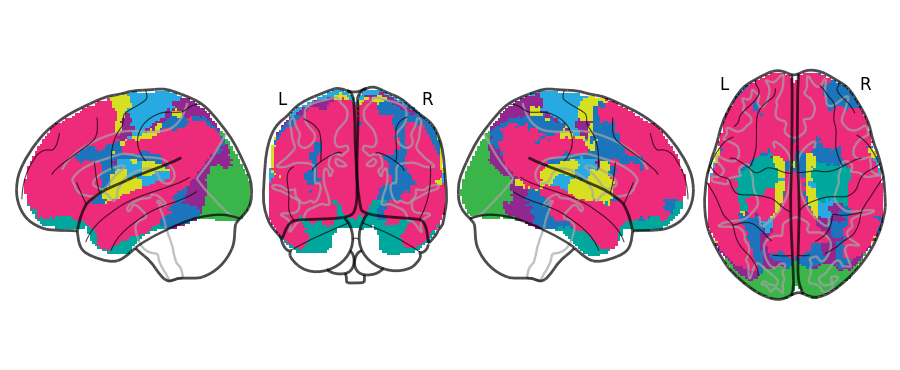

<Figure size 640x480 with 0 Axes>

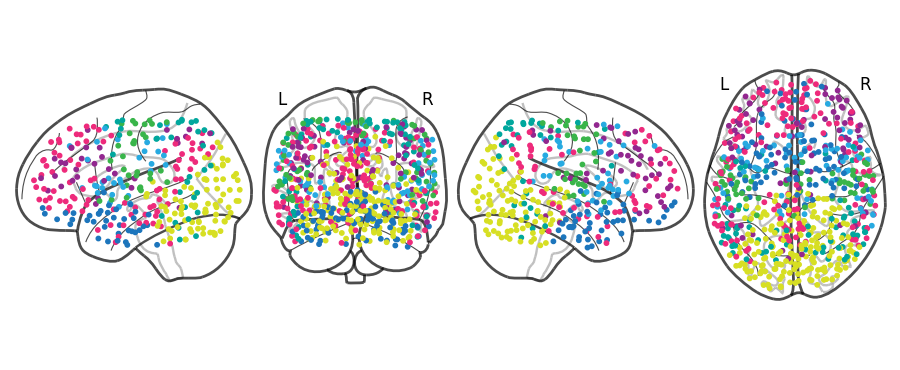

<Figure size 640x480 with 0 Axes>

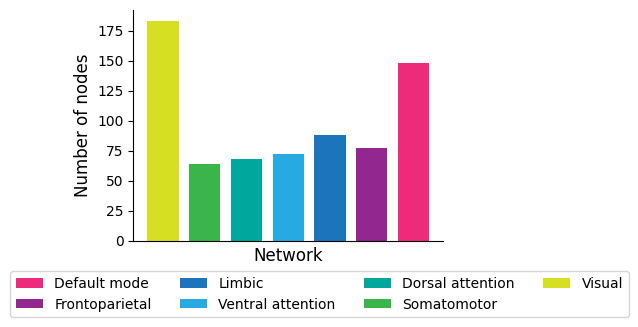

In [22]:
key = os.path.join('data/pieman/raw/Schaefer2018_1000Parcels_7Networks_order.txt')
key = pd.read_csv(key, sep='\t', header=None, names=['id', 'name', 'x', 'y', 'z', 't']).drop('t', axis=1)
key['study'] = key['name'].apply(lambda x: x.split('_')[0])
key['hemisphere'] = key['name'].apply(lambda x: x.split('_')[1][0])
key['network'] = key['name'].apply(lambda x: x.split('_')[2])
key.drop('name', axis=1, inplace=True)

lookup_table = {
    'Vis': 'Visual',
    'SomMot': 'Somatomotor',
    'DorsAttn': 'Dorsal attention',
    'SalVentAttn': 'Ventral attention',
    'Limbic': 'Limbic',
    'Cont': 'Frontoparietal',
    'Default': 'Default mode'
}

network_colors = {
    'Visual': '#D7DF23',
    'Somatomotor': '#39B54A',
    'Dorsal attention': '#00A79D',
    'Ventral attention': '#27AAE1',
    'Limbic': '#1C75BC',
    'Frontoparietal': '#92278F',
    'Default mode': '#EE2A7B'
}

colors = ['#888888']
colors.extend([v for k, v in network_colors.items()])
network_cmap = ListedColormap(colors, N=len(colors)*2, name='networks')  # why do I need to double the number of colors?

network_codes = {k: i + 1 for i, k in enumerate(lookup_table.values())}

key['network'] = key['network'].apply(lambda x: lookup_table[x])
key['code'] = key['network'].apply(lambda x: network_codes[x])
key.set_index('id', inplace=True)
key.loc[0, 'code'] = 0  # append a background (non-network) code
key           # pip: nibabel==5.0.1

my_cmap = ListedColormap(network_colors.values())
nii_fname = os.path.join('data/pieman/raw/Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_2mm.nii.gz')
n_x = nlt.Brain_Data(nii_fname)
n_x.data = np.array([key.loc[i, 'code'] for i in n_x.data]).astype(float)
networks = n_x.to_nifti()
nl.plotting.plot_glass_brain(networks, cmap=network_cmap, display_mode='lyrz')
plt.show()
plt.clf()

# load network parcellations in CMU format
networks_cmu = nii2cmu(nii_fname)

# covert voxel values in the reference image to network codes
networks_cmu['Y'] = np.atleast_2d(np.array([key.loc[i, 'code'] for i in networks_cmu['Y']]).astype(float))
node_codes = node_labels(centers, widths, networks_cmu)
node_codes

nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_size=10, node_color=[colors[i] for i in node_codes['code']], display_mode='lyrz')
# add legend
plt.show()
plt.clf()

network_legend_list = list(network_colors.keys())
network_legend_list.reverse()
node_codes = node_labels(centers, widths, networks_cmu)
node_codes

fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes, x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
ax.legend(network_legend_list, loc='upper center', bbox_to_anchor=(0.6, -0.1),
          fancybox=True, ncol=4)
plt.show()
plt.clf()
fig.savefig(os.path.join('htfa_node_counts.pdf'), bbox_inches='tight')



In [50]:
all_results[c]['C']

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [51]:
for c in ['intact', 'word', 'rest']:
    recon = build_recon_stack(all_results[c]["results_subj"], all_results[c]['C'], basis="group", zscore_time=True, zscore_nodes=False)  # (N, T, V)
    results_pd = run_timepoint_decoding(recon, nfolds=2, nreps=10, seed=123)
    print(c)
    print(results_pd.groupby(['fold']).mean(numeric_only=True))

intact
          rank  accuracy     error  rep
fold                                   
0     0.916917  0.134429  0.297308  4.5
1     0.916788  0.136571  0.296526  4.5
word
          rank  accuracy     error  rep
fold                                   
0     0.782624  0.023714  0.325114  4.5
1     0.782568  0.027143  0.319728  4.5
rest
          rank  accuracy     error  rep
fold                                   
0     0.599109  0.003714  0.336396  4.5
1     0.598829  0.004000  0.335170  4.5


In [ ]:
# nreps = 2
# for c in cond_list:

#     recon = build_recon_stack(all_results[c]["results_subj"], all_results[c]['C'], basis="group", zscore_time=True, zscore_nodes=False)  # (N, T, V)
#     results_pd = run_timepoint_decoding(recon, nfolds=2, nreps=nreps, seed=123)
#     print(c)
#     print(results_pd.groupby(['fold']).mean(numeric_only=True))
    
#     subs = all_results[c]["results_subj"]
#     per_arch_df = per_archetype_coeff_decoding(subs, nfolds=2, nreps=nreps, seed=123, window_radius=3)
#     print(c, "— top 10 archetypes by accuracy:")
#     print(per_arch_df.groupby("archetype")["accuracy"].mean().sort_values(ascending=False).head(10))
#     freq_selected_k = per_arch_df.groupby("archetype")["accuracy"].mean().sort_values(ascending=False).head(10).index.to_numpy()
    
#     # 2) Subset reconstruction using top-m archetypes ranked by in-fold ISC
#     top_ms = (1, 2, 3, 4, 5, 10, 15, 25, 50)  # adjust to your K
#     # top_ms = [1,2,3,4,5]
#     subset_df = run_timepoint_decoding_topm_by_isc(all_results[c]['C'], all_results[c]["results_subj"], top_ms=top_ms, nfolds=2, nreps=nreps, seed=42)

#     print("\n", c, "— accuracy vs number of archetypes (mean over reps/folds):")
#     print(subset_df.groupby("top_m")["accuracy"].mean())

#     # Optional: see which archetypes are consistently selected
#     K = C.shape[1]
#     counts = np.zeros(K, dtype=int)
#     for idxs in subset_df["selected_idxs"]:
#         counts[idxs] += 1
#     top_stable = np.argsort(-counts)[:10]
#     print("Most frequently selected archetypes:", top_stable)


In [65]:

# Collect everything here
all_summaries = {}

nreps = 200  # or whatever you want
for c in cond_list:
    # 1) Timepoint decoding on reconstructions
    recon = build_recon_stack(
        all_results[c]["results_subj"],
        all_results[c]['C'],
        basis="group",
        zscore_time=True,
        zscore_nodes=True
    )  # (N, T, V)

    results_pd = run_timepoint_decoding(recon, nfolds=2, nreps=nreps, seed=123)
    print(c)
    print(results_pd.groupby(['fold']).mean(numeric_only=True))

    # 2) Per-archetype coeff decoding
    subs = all_results[c]["results_subj"]
    per_arch_df = per_archetype_coeff_decoding(
        subs, nfolds=2, nreps=nreps, seed=123, window_radius=3
    )

    top10_per_arch = (
        per_arch_df.groupby("archetype")["accuracy"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    print(c, "— top 10 archetypes by accuracy:")
    print(top10_per_arch)

    freq_selected_k = top10_per_arch.index.to_numpy()

    # 3) Subset reconstruction using top-m archetypes ranked by in-fold ISC
    top_ms = (1, 2, 3, 4, 5, 10, 15, 25, 50)  # adjust to your K
    subset_df = run_timepoint_decoding_topm_by_isc(
        all_results[c]['C'],
        all_results[c]["results_subj"],
        top_ms=top_ms,
        nfolds=2,
        nreps=nreps,
        seed=42
    )

    print("\n", c, "— accuracy vs number of archetypes (mean over reps/folds):")
    acc_vs_topm = subset_df.groupby("top_m")["accuracy"].mean()
    print(acc_vs_topm)

    # 4) Stability: which archetypes are most frequently selected
    K = all_results[c]['C'].shape[1]   # <-- use the C for this condition
    counts = np.zeros(K, dtype=int)
    for idxs in subset_df["selected_idxs"]:
        counts[idxs] += 1
    top_stable = np.argsort(-counts)[:10]
    print("Most frequently selected archetypes:", top_stable)

    # 5) Store everything for this condition
    all_summaries[c] = {
        "recon_shape": recon.shape,                           # (N,T,V)
        "timepoint_decoding": results_pd,                     # full df
        "timepoint_decoding_by_fold": (
            results_pd.groupby(['fold']).mean(numeric_only=True)
        ),
        "per_archetype_decoding": per_arch_df,                # full df
        "per_archetype_top10": top10_per_arch,                # Series
        "freq_selected_k": freq_selected_k,                   # np.array of archetype ids
        "subset_decoding": subset_df,                         # full df
        "acc_vs_topm": acc_vs_topm,                           # Series
        "selected_counts": pd.Series(counts),                 # how often each k was picked
        "top_stable_k": top_stable,                           # np.array of top k by frequency
        "K": K
    }

# Optional: quick glance
for c in all_summaries:
    print(f"\n[{c}] best archetypes (by per-arch accuracy):", all_summaries[c]["per_archetype_top10"].index.to_list())
    print(f"[{c}] top-stable archetypes:", all_summaries[c]["top_stable_k"])


intact
          rank  accuracy     error   rep
fold                                    
0     0.920140  0.138121  0.294858  99.5
1     0.920116  0.140007  0.294377  99.5
intact — top 10 archetypes by accuracy:
archetype
2    0.180661
0    0.180525
1    0.167832
3    0.125557
4    0.112504
5    0.068857
7    0.057150
6    0.053271
8    0.043243
9    0.041675
Name: accuracy, dtype: float64

 intact — accuracy vs number of archetypes (mean over reps/folds):
top_m
1     0.002411
2     0.003657
3     0.005743
4     0.009332
5     0.015407
10    0.054150
15    0.081725
25    0.114479
50    0.134861
Name: accuracy, dtype: float64
Most frequently selected archetypes: [0 1 2 3 4 5 6 7 8 9]
word
          rank  accuracy     error   rep
fold                                    
0     0.786502  0.027721  0.322511  99.5
1     0.786518  0.027729  0.322802  99.5
word — top 10 archetypes by accuracy:
archetype
0    0.102125
1    0.089321
3    0.088311
2    0.086329
4    0.070914
5    0.065532
7    0.0

In [ ]:
# your existing loop over conditions
for c in cond_list:
    subjects = all_results[c]["results_subj"]

    # 1) Per-archetype coefficient-space decoding (temporal window)
    per_arch = per_archetype_coeff_decoding(subjects, nfolds=2, nreps=100, seed=42, window_radius=3)
    print("\n", c, "— top 10 archetypes by coeff-space decoding:")
    print(per_arch.groupby("archetype")["accuracy"].mean().sort_values(ascending=False).head(10))

    # 2) Subset reconstruction using top-m archetypes ranked by in-fold ISC
    top_ms = (1, 2, 3, 4, 5, 10, 15, 25, 50)  # adjust to your K
    # top_ms = [1,2,3,4,5]
    subset_df = run_timepoint_decoding_topm_by_isc(C, subjects, top_ms=top_ms, nfolds=2, nreps=100, seed=42)

    print("\n", c, "— accuracy vs number of archetypes (mean over reps/folds):")
    print(subset_df.groupby("top_m")["accuracy"].mean())

    # Optional: see which archetypes are consistently selected
    K = C.shape[1]
    counts = np.zeros(K, dtype=int)
    for idxs in subset_df["selected_idxs"]:
        counts[idxs] += 1
    top_stable = np.argsort(-counts)[:10]
    print("Most frequently selected archetypes:", top_stable)


In [67]:
# Given:
#   C: (700, k)
#   all_results[cond]["results_subj"] = list of 36 dicts with keys "sXC" (300×k), "S" (k×700)

for c in cond_list:
    subjects = all_results[c]["results_subj"]
    C_mat = all_results[c]["C"]

    # Learn weights and decode (weighted)
    metrics_w, weights_w = run_weighted_timepoint_decoding(
        C_mat, subjects,
        nfolds=2, nreps=100, seed=123,
        l2=1e-2,        # try 1e-3 → 1e-1
        use_abs=False,  # set True if sign flips are hurting you
        zscore_time=True
    )

    print(f"\n{c} — weighted decoding (mean over reps/folds):")
    print(metrics_w.groupby("fold").mean(numeric_only=True)[["accuracy","rank","error"]])

    # Aggregate the weights to see which archetypes matter
    w_cols = [col for col in weights_w.columns if col.startswith("w_")]
    mean_w = weights_w[w_cols].mean(axis=0).values
    order = np.argsort(-mean_w)
    print("Top archetypes by mean learned weight:", order[:10])

    # OPTIONAL: map weights to networks if you have a node2net array of length 700
    # node2net = ... # array of ints 0..G-1
    # prof = network_weight_profile(C, mean_w, node2net, agg='l2')
    # print(prof.sort_values("score", ascending=False).head(10))



intact — weighted decoding (mean over reps/folds):
      accuracy      rank     error
fold                              
0     0.134014  0.916381  0.294991
1     0.132929  0.916631  0.295894
Top archetypes by mean learned weight: [ 2  4  0  1  3  5  6 12  7 19]

word — weighted decoding (mean over reps/folds):
      accuracy      rank     error
fold                              
0     0.027914  0.784088  0.323523
1     0.028457  0.784156  0.323204
Top archetypes by mean learned weight: [ 0  2  1  3  6  4  5  7  8 32]

rest — weighted decoding (mean over reps/folds):
      accuracy      rank     error
fold                              
0     0.003771  0.597784  0.332118
1     0.003814  0.595446  0.333930
Top archetypes by mean learned weight: [ 0  1 12  3  2 17  5 11  7 14]


In [ ]:
# Given:
#   C: (700, k)
#   all_results[cond]["results_subj"] = list of 36 dicts with keys "sXC" (300×k), "S" (k×700)

for c in cond_list:
    subjects = all_results[c]["results_subj"]
    C_mat = all_results[c]["C"]

    # Learn weights and decode (weighted)
    metrics_w, weights_w = run_weighted_timepoint_decoding(
        C_mat, subjects,
        nfolds=2, nreps=100, seed=123,
        l2=1e-2,        # try 1e-3 → 1e-1
        use_abs=False,  # set True if sign flips are hurting you
        zscore_time=True
    )

    print(f"\n{c} — weighted decoding (mean over reps/folds):")
    print(metrics_w.groupby("fold").mean(numeric_only=True)[["accuracy","rank","error"]])

    # Aggregate the weights to see which archetypes matter
    w_cols = [col for col in weights_w.columns if col.startswith("w_")]
    mean_w = weights_w[w_cols].mean(axis=0).values
    order = np.argsort(-mean_w)
    print("Top archetypes by mean learned weight:", order[:10])

    # OPTIONAL: map weights to networks if you have a node2net array of length 700
    # node2net = ... # array of ints 0..G-1
    # prof = network_weight_profile(C, mean_w, node2net, agg='l2')
    # print(prof.sort_values("score", ascending=False).head(10))
